# NYC Taxi Data Pipeline & Modeling
This notebook uses cleaned NYC taxi trip data processed with Hadoop/HDFS and PySpark. The goal is to predict congestion levels and analyze patterns in taxi trips, traffic speed, and weather.

# Load Data

In [ ]:
#Install PySpark
!pip install pyspark

#Import SparkSession
from pyspark.sql import SparkSession

#Start Spark session
spark = SparkSession.builder \
    .appName("NYC Taxi Congestion Project") \
    .getOrCreate()

print("Spark is running")

Spark is running


In [ ]:
#Mount Google Drive so we can access shared project datasets
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Load cleaned taxi dataset from Google Drive
df = spark.read.parquet("/content/drive/MyDrive/cleaned_taxi_data")

#Preview the data
df.show(5)
df.printSchema()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-------------+----+-----------+------------------+----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|trip_duration|hour|day_of_week|             speed|congestion|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-------------+----+-----------+------------------+----------+
|   

In [ ]:
#Load cleaned taxi dataset from Google Drive
weather_df = spark.read.parquet("/content/nyc_weather_cleaned")

#Preview the data
weather_df.printSchema()
weather_df.show(5)

root
 |-- date: string (nullable = true)
 |-- tmax: integer (nullable = true)
 |-- tmin: integer (nullable = true)
 |-- tavg: double (nullable = true)
 |-- precipitation: double (nullable = true)
 |-- new_snow: double (nullable = true)
 |-- snow_depth: double (nullable = true)

+--------+----+----+----+-------------+--------+----------+
|    date|tmax|tmin|tavg|precipitation|new_snow|snow_depth|
+--------+----+----+----+-------------+--------+----------+
|01/01/23|  60|  40|50.0|         0.08|     0.0|       0.0|
|01/02/23|  41|  35|38.0|          0.0|     0.0|       0.0|
|01/03/23|  45|  39|42.0|         0.01|     0.0|       0.0|
|01/04/23|  47|  37|42.0|          0.0|     0.0|       0.0|
|01/05/23|  47|  42|44.5|         0.45|     0.0|       0.0|
+--------+----+----+----+-------------+--------+----------+
only showing top 5 rows


# Join Data

In [ ]:
from pyspark.sql.functions import col, to_date

#Create date column from taxi pickup datetime
df = df.withColumn(
    "date",
    to_date(col("tpep_pickup_datetime"))
)

#Convert weather date from string format MM/dd/yy to a real date
weather_df = weather_df.withColumn(
    "date",
    to_date(col("date"), "MM/dd/yy")
)

#Join taxi data with weather data using date
df_joined = df.join(
    weather_df,
    on="date",
    how="left"
)

#Preview combined dataset
df_joined.select(
    "date",
    "trip_distance",
    "trip_duration",
    "speed",
    "congestion",
    "tavg",
    "precipitation",
    "new_snow",
    "snow_depth"
).show(10)

+----------+-------------+-------------+------------------+----------+----+-------------+--------+----------+
|      date|trip_distance|trip_duration|             speed|congestion|tavg|precipitation|new_snow|snow_depth|
+----------+-------------+-------------+------------------+----------+----+-------------+--------+----------+
|2023-01-01|         0.97|          506| 6.901185770750988|      High|50.0|         0.08|     0.0|       0.0|
|2023-01-01|          1.1|          379|10.448548812664908|    Medium|50.0|         0.08|     0.0|       0.0|
|2023-01-01|         2.51|          765|11.811764705882352|    Medium|50.0|         0.08|     0.0|       0.0|
|2023-01-01|          1.9|          577|11.854419410745233|    Medium|50.0|         0.08|     0.0|       0.0|
|2023-01-01|         1.43|          650|              7.92|      High|50.0|         0.08|     0.0|       0.0|
|2023-01-01|         1.84|          738| 8.975609756097562|      High|50.0|         0.08|     0.0|       0.0|
|2023-01-0

# Congestion Label

In [ ]:
from pyspark.ml.feature import StringIndexer

#Convert congestion categories into numeric labels for machine learning
#Example: High, Medium, Low to 0, 1, 2
indexer = StringIndexer(inputCol="congestion", outputCol="label")

df = indexer.fit(df).transform(df)

#Check label conversion
df.select("congestion", "label").show(5)

+----------+-----+
|congestion|label|
+----------+-----+
|      High|  0.0|
|    Medium|  1.0|
|    Medium|  1.0|
|    Medium|  1.0|
|      High|  0.0|
+----------+-----+
only showing top 5 rows


# Model 1: Random Forest with All Features

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

#Features used for prediction
feature_cols = ["trip_distance", "trip_duration", "speed", "hour", "day_of_week"]

#Combine selected columns into one features vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

df_ml = assembler.transform(df)

#Split into training and testing sets
train, test = df_ml.randomSplit([0.8, 0.2], seed=42)

#Create Random Forest model
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=20
)

#Train model
model = rf.fit(train)

#Make predictions
predictions = model.transform(test)

#Evaluate accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.9750056028221623


# Model 2: Without Leakage Features

In [ ]:
#This model removes speed and trip_duration because they may leak congestion information
feature_cols_no_leakage = ["trip_distance", "hour", "day_of_week"]

assembler_no_leakage = VectorAssembler(
    inputCols=feature_cols_no_leakage,
    outputCol="features_no_leakage"
)

df_ml_no_leakage = assembler_no_leakage.transform(df)

train2, test2 = df_ml_no_leakage.randomSplit([0.8, 0.2], seed=42)

rf2 = RandomForestClassifier(
    labelCol="label",
    featuresCol="features_no_leakage",
    numTrees=20
)

model2 = rf2.fit(train2)

predictions2 = model2.transform(test2)

accuracy2 = evaluator.evaluate(predictions2)

print("Random Forest Accuracy Without Speed/Duration:", accuracy2)

Random Forest Accuracy Without Speed/Duration: 0.6805760531230546


# Model Metrics

In [ ]:
#Evaluate precision and recall for the first model
precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

print("Accuracy:", accuracy)
print("Precision:", precision_eval.evaluate(predictions))
print("Recall:", recall_eval.evaluate(predictions))

Accuracy: 0.9750056028221623
Precision: 0.9761323811218459
Recall: 0.9750056028221622


# Visualizations

In [ ]:
# Import graph libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Take a sample from the JOINED dataset for faster graphing
# df_joined includes both taxi data and weather data
pdf = df_joined.sample(fraction=0.1, seed=42).toPandas()

#Remove extreme outliers so graphs are easier to read

#Keep only realistic trip distances
pdf = pdf[pdf["trip_distance"] > 0]
pdf = pdf[pdf["trip_distance"] < 20]

#Keep only realistic trip durations
pdf = pdf[pdf["trip_duration"] > 60]
pdf = pdf[pdf["trip_duration"] < 5000]

#Keep only realistic speeds
pdf = pdf[pdf["speed"] > 0]
pdf = pdf[pdf["speed"] < 100]

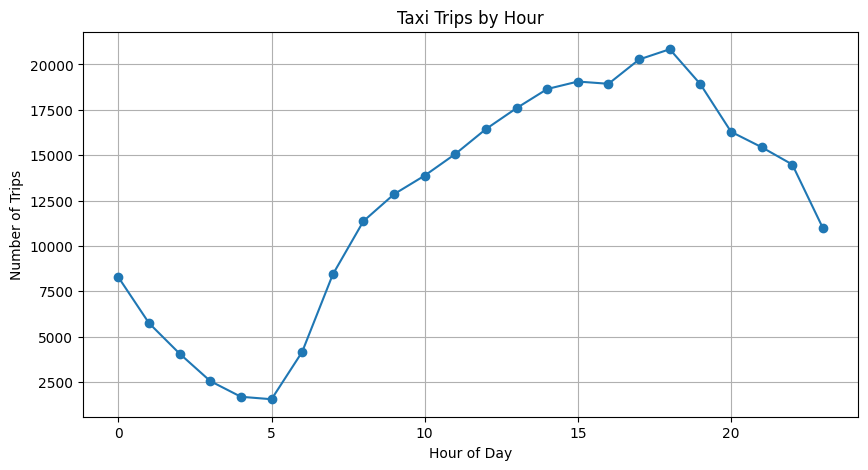

In [ ]:
#Graph 1: Trips by Hour

#Count number of trips by hour
hour_counts = pdf.groupby("hour").size()

plt.figure(figsize=(10,5))
plt.plot(hour_counts.index, hour_counts.values, marker="o")

plt.title("Taxi Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.show()

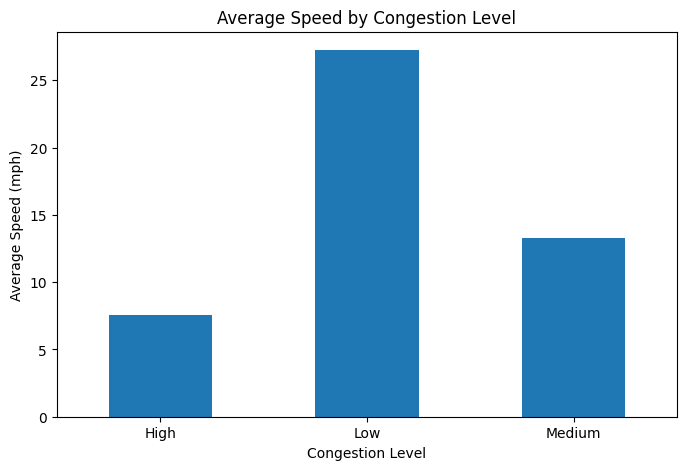

In [ ]:
#Graph 2: Average Speed by Congestion

#Calculate average speed for each congestion level
avg_speed = pdf.groupby("congestion")["speed"].mean()

plt.figure(figsize=(8,5))
avg_speed.plot(kind="bar")

plt.title("Average Speed by Congestion Level")
plt.xlabel("Congestion Level")
plt.ylabel("Average Speed (mph)")
plt.xticks(rotation=0)
plt.show()

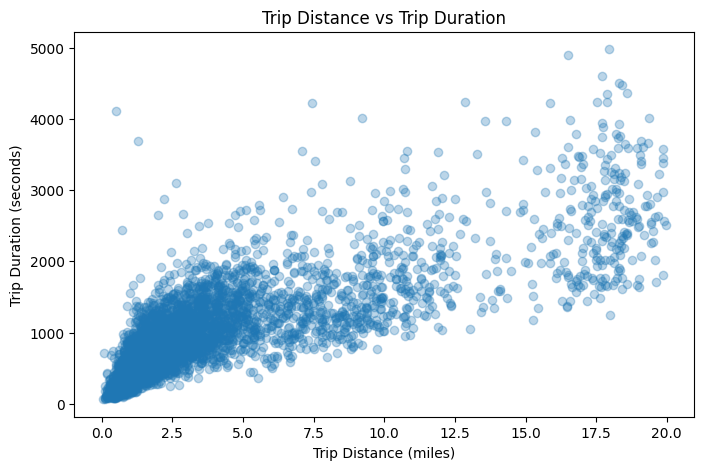

In [ ]:
#Graph 3: Distance vs Duration

#Take smaller sample so scatter plot is readable
pdf_small = pdf.sample(frac=0.02, random_state=42)

plt.figure(figsize=(8,5))
plt.scatter(
    pdf_small["trip_distance"],
    pdf_small["trip_duration"],
    alpha=0.3
)

plt.title("Trip Distance vs Trip Duration")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Trip Duration (seconds)")
plt.show()

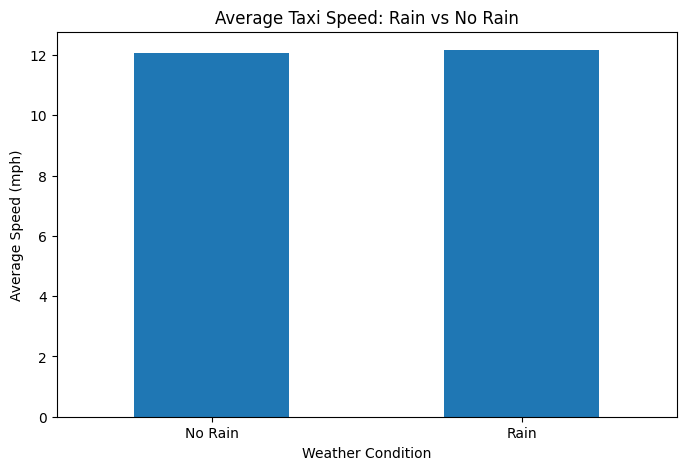

In [ ]:
#Graph 4: Weather Graph

#Create rain/no rain category from precipitation
pdf["rain_day"] = pdf["precipitation"].apply(lambda x: "Rain" if x > 0 else "No Rain")

#Calculate average speed for rain vs no rain days
rain_speed = pdf.groupby("rain_day")["speed"].mean()

plt.figure(figsize=(8,5))
rain_speed.plot(kind="bar")

plt.title("Average Taxi Speed: Rain vs No Rain")
plt.xlabel("Weather Condition")
plt.ylabel("Average Speed (mph)")
plt.xticks(rotation=0)
plt.show()

# Key Insights

- Taxi trip volume changes throughout the day, with higher demand during daytime and evening hours.
- Average speed decreases as congestion increases, confirming that speed is strongly related to congestion level.
- Distance and duration show a positive relationship, but traffic conditions create variation.
- Weather did not significantly improve model performance, suggesting that time based and trip  based features were stronger predictors than daily weather summaries.
- Some features like speed and trip duration may introduce data leakage because they are closely tied to congestion.